# Employee Promotion Prediction using Machine Learning

**Project:** Analysis and Prediction Using Machine Learning Techniques
**Institution:** Techolas Technologies, Calicut
**Author:** [Your Name]
**Date:** [Date]

---

## 1. Introduction

### Problem Statement
HR departments spend a huge amount of time manually reviewing employee records to decide promotions. This is slow, subjective, and often delayed. The goal of this project is to build a **machine learning model that predicts whether an employee will be promoted** based on features like department, education, training scores, service length, and performance ratings.

### Importance
- **Faster decisions:** Reduces the HR workload.
- **Fairness:** Model treats every employee using the same rules.
- **Business value:** Helps companies plan succession and training early.


## 2. Dataset Overview

- **Source:** HR Analytics dataset (`employee.csv`)
- **Description:** 54,808 employee records with 13 columns.
- **Target variable:** `is_promoted` (0 = Not Promoted, 1 = Promoted) — binary classification.

### Features
| Column | Description |
|---|---|
| employee_id | Unique ID (dropped before modeling) |
| department | Department of the employee |
| region | Region of employment |
| education | Education level |
| gender | Gender (m/f) |
| recruitment_channel | How the employee was recruited |
| no_of_trainings | Number of trainings taken |
| age | Age in years |
| previous_year_rating | Rating from previous year (1–5) |
| length_of_service | Years with the company |
| awards_won? | Whether they won awards last year |
| avg_training_score | Average score in training evaluations |
| is_promoted | **Target** |


## 3. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")

## 4. Data Understanding

Every method listed in the guidelines PDF.

In [2]:
df = pd.read_csv("employee.csv")
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [3]:
df.tail()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
54803,3030,Technology,region_14,Bachelor's,m,sourcing,1,48,3.0,17,0,78,0
54804,74592,Operations,region_27,Master's & above,f,other,1,37,2.0,6,0,56,0
54805,13918,Analytics,region_1,Bachelor's,m,other,1,27,5.0,3,0,79,0
54806,13614,Sales & Marketing,region_9,NaN,m,sourcing,1,29,1.0,2,0,45,0
54807,51526,HR,region_22,Bachelor's,m,other,1,27,1.0,5,0,49,0


In [4]:
print("Shape:", df.shape)
print("Size:", df.size)

Shape: (54808, 13)
Size: 712504


In [5]:
df.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'awards_won?', 'avg_training_score',
       'is_promoted'],
      dtype='str')

In [6]:
df.dtypes

employee_id               int64
department                  str
region                      str
education                   str
gender                      str
recruitment_channel         str
no_of_trainings           int64
age                       int64
previous_year_rating    float64
length_of_service         int64
awards_won?               int64
avg_training_score        int64
is_promoted               int64
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  str    
 2   region                54808 non-null  str    
 3   education             52399 non-null  str    
 4   gender                54808 non-null  str    
 5   recruitment_channel   54808 non-null  str    
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 7.5 MB


In [8]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,99.000000,1.000000


In [9]:
# Unique values per column
for c in df.columns:
    print(f"{c}: {df[c].nunique()} unique values")

employee_id: 54808 unique values
department: 9 unique values
region: 34 unique values
education: 3 unique values
gender: 2 unique values
recruitment_channel: 3 unique values
no_of_trainings: 10 unique values
age: 41 unique values
previous_year_rating: 5 unique values
length_of_service: 35 unique values
awards_won?: 2 unique values
avg_training_score: 61 unique values
is_promoted: 2 unique values


In [10]:
# value_counts() for the target
df["is_promoted"].value_counts()

is_promoted
0    50140
1     4668
Name: count, dtype: int64

In [11]:
# Correlation matrix (numeric features)
df.select_dtypes(include=np.number).corr()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
employee_id,1.000000,-0.005121,0.000437,0.004533,0.001274,0.008420,-0.000586,0.001206
no_of_trainings,-0.005121,1.000000,-0.081278,-0.063126,-0.057275,-0.007628,0.042517,-0.024896
age,0.000437,-0.081278,1.000000,0.006008,0.657111,-0.008169,-0.048380,-0.017166
previous_year_rating,0.004533,-0.063126,0.006008,1.000000,0.000253,0.027738,0.075139,0.159320
length_of_service,0.001274,-0.057275,0.657111,0.000253,1.000000,-0.039927,-0.038122,-0.010670
awards_won?,0.008420,-0.007628,-0.008169,0.027738,-0.039927,1.000000,0.072138,0.195871
avg_training_score,-0.000586,0.042517,-0.048380,0.075139,-0.038122,0.072138,1.000000,0.181147
is_promoted,0.001206,-0.024896,-0.017166,0.159320,-0.010670,0.195871,0.181147,1.000000


## 5. Exploratory Data Analysis

### Insights we want to check
1. Is the target imbalanced?
2. Which departments promote the most?
3. Does `avg_training_score` differ between promoted vs not-promoted?
4. Which features are most correlated with the target?


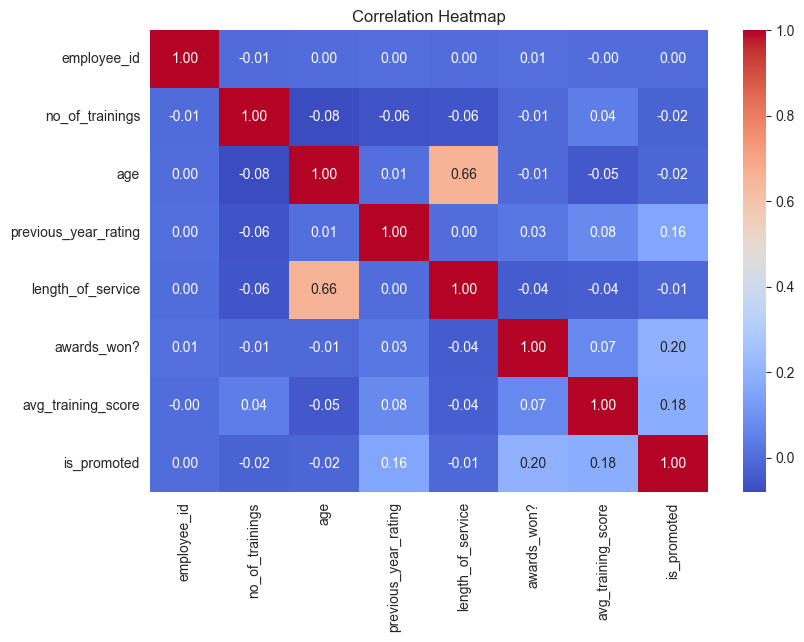

In [12]:
# Heatmap — correlation between numeric features
plt.figure(figsize=(9, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

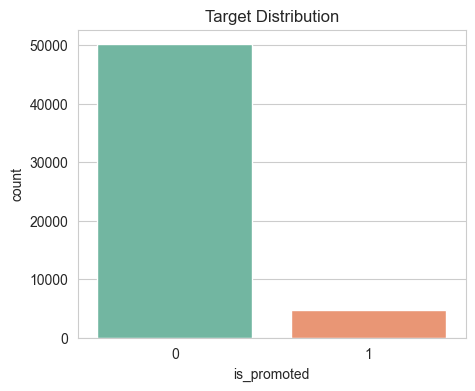

Class imbalance ratio: 10.74 : 1


In [13]:
# Target distribution — shows class imbalance
plt.figure(figsize=(5, 4))
sns.countplot(x="is_promoted", data=df, palette="Set2")
plt.title("Target Distribution")
plt.show()

print("Class imbalance ratio:",
      round(df["is_promoted"].value_counts()[0] / df["is_promoted"].value_counts()[1], 2),
      ": 1")

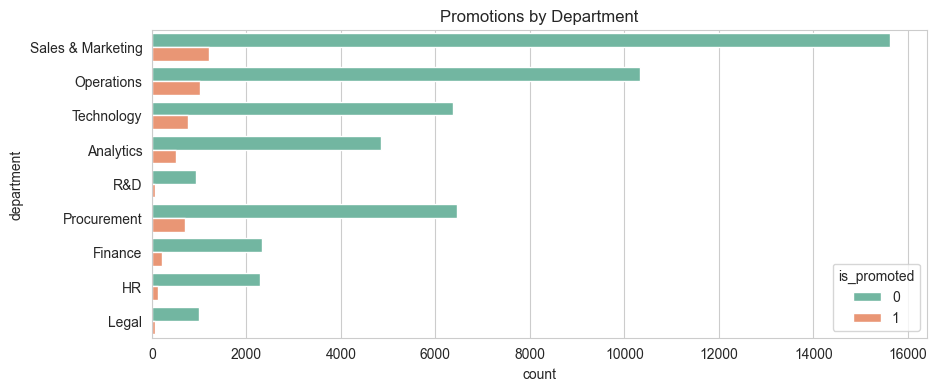

In [14]:
# Count plot — promotions by department
plt.figure(figsize=(10, 4))
sns.countplot(y="department", hue="is_promoted", data=df, palette="Set2")
plt.title("Promotions by Department")
plt.show()

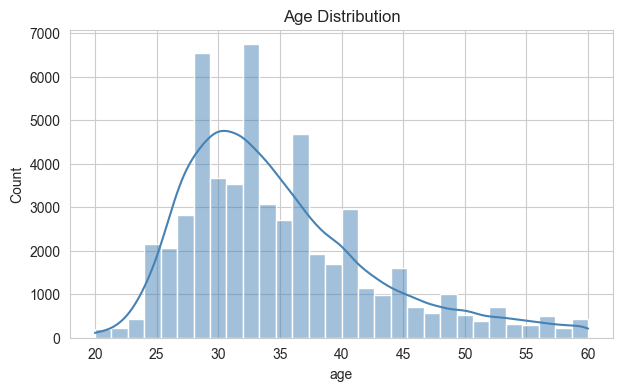

In [15]:
# Histogram — age distribution
plt.figure(figsize=(7, 4))
sns.histplot(df["age"], bins=30, kde=True, color="steelblue")
plt.title("Age Distribution")
plt.show()

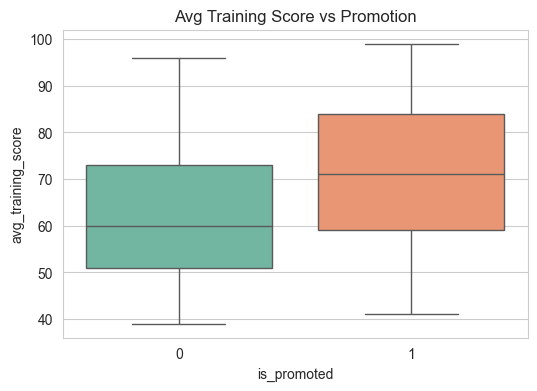

In [16]:
# Box plot — training score vs promotion
plt.figure(figsize=(6, 4))
sns.boxplot(x="is_promoted", y="avg_training_score", data=df, palette="Set2")
plt.title("Avg Training Score vs Promotion")
plt.show()

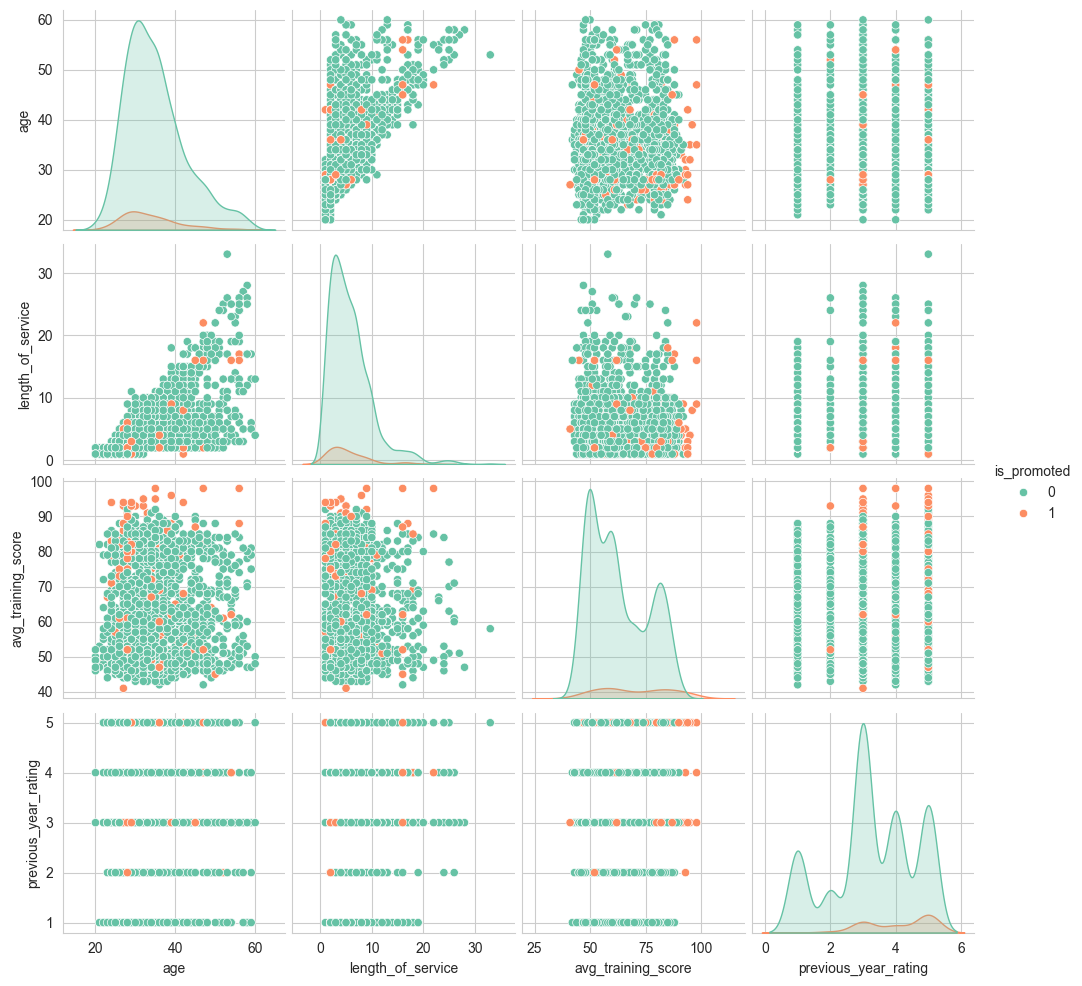

In [17]:
# Pair plot on a sample (full dataset is too big)
sample = df.sample(2000, random_state=42)
sns.pairplot(sample[["age", "length_of_service", "avg_training_score",
                     "previous_year_rating", "is_promoted"]],
             hue="is_promoted", palette="Set2")
plt.show()

### EDA Insights (Summary)

- **Severe class imbalance** — about 91% of employees are *not* promoted. We must handle this before training.
- **avg_training_score** is the single most predictive feature — promoted employees clearly score higher.
- **previous_year_rating** and **awards_won?** are also strongly linked to promotion.
- Sales & Marketing and Operations have the most promotions in absolute numbers (they are the largest departments).
- Age alone is not a strong predictor; most employees cluster between 28–40.


## 6. Data Preprocessing

### Steps
1. Drop `employee_id` (not useful).
2. Fill missing values in `education` (mode) and `previous_year_rating` (median).
3. Encode categorical columns with `LabelEncoder`.
4. Scale features with `StandardScaler`.
5. Split into train/test.
6. Handle class imbalance using **SMOTE** (oversampling minority class).


In [18]:
# Missing values check
df.isnull().sum()

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [19]:
data = df.drop(columns=["employee_id"]).copy()

# Fill missing values
data["education"] = data["education"].fillna(data["education"].mode()[0])
data["previous_year_rating"] = data["previous_year_rating"].fillna(
    data["previous_year_rating"].median())

print("Missing after fill:", data.isnull().sum().sum())

Missing after fill: 0


In [20]:
# Encode categorical columns
cat_cols = data.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", cat_cols)

for c in cat_cols:
    data[c] = LabelEncoder().fit_transform(data[c])

data.head()

Categorical columns: ['department', 'region', 'education', 'gender', 'recruitment_channel']


,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,7,31,2,0,2,1,35,5.0,8,0,49,0
1,4,14,0,1,0,1,30,5.0,4,0,60,0
2,7,10,0,1,2,1,34,3.0,7,0,50,0
3,7,15,0,1,0,2,39,1.0,10,0,50,0
4,8,18,0,1,0,1,45,3.0,2,0,73,0


In [21]:
# Features & target
X = data.drop(columns=["is_promoted"])
y = data["is_promoted"]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (43846, 11)  Test: (10962, 11)


In [22]:
# Handle imbalance with SMOTE (only on training set!)
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_bal))

Before SMOTE: [40112  3734]
After SMOTE: [40112 40112]


## 7. Hyperparameter Tuning and Cross-Validation

### Why hyperparameters matter
Hyperparameters are settings we choose *before* training (e.g., `n_neighbors` for KNN, `max_depth` for a tree). Different values produce very different models.

### Why cross-validation
Instead of trusting one train/test split, we split the training data into **K folds**, train on K−1 and validate on the remaining fold, rotating. This gives a much more reliable estimate of model quality.

### GridSearchCV
GridSearchCV tries every combination of hyperparameters we give it, runs K-fold CV for each, and picks the combo with the best score.


## 8. Model Building

We will train **four classification models** covered in class:

1. **Logistic Regression** — linear model, outputs probabilities.
2. **K-Nearest Neighbors (KNN)** — predicts based on the K closest training points.
3. **Decision Tree** — splits data into if/else rules.
4. **Random Forest** — an ensemble of many decision trees.


In [23]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models_config = {
    "Logistic Regression": (
        LogisticRegression(max_iter=500, random_state=42),
        {"C": [0.1, 1.0]}
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"n_neighbors": [5, 11]}
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {"max_depth": [6, 10]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {"n_estimators": [100], "max_depth": [10, None]}
    ),
}

results = {}
best_models = {}

for name, (estimator, grid) in models_config.items():
    print(f"\n--- Training {name} ---")
    gs = GridSearchCV(estimator, grid, cv=cv, scoring="f1", n_jobs=-1)
    gs.fit(X_train_bal, y_train_bal)
    best_models[name] = gs.best_estimator_

    y_pred = gs.predict(X_test)
    y_proba = gs.predict_proba(X_test)[:, 1]

    results[name] = {
        "best_params": gs.best_params_,
        "accuracy": round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred), 4),
        "recall": round(recall_score(y_test, y_pred), 4),
        "f1": round(f1_score(y_test, y_pred), 4),
        "roc_auc": round(roc_auc_score(y_test, y_proba), 4),
    }
    print(results[name])


--- Training Logistic Regression ---
{'best_params': {'C': 0.1}, 'accuracy': 0.6829, 'precision': 0.1621, 'recall': 0.6531, 'f1': 0.2598, 'roc_auc': np.float64(0.7432)}

--- Training KNN ---
{'best_params': {'n_neighbors': 5}, 'accuracy': 0.7691, 'precision': 0.1792, 'recall': 0.4775, 'f1': 0.2606, 'roc_auc': np.float64(0.6722)}

--- Training Decision Tree ---
{'best_params': {'max_depth': 10}, 'accuracy': 0.8712, 'precision': 0.3091, 'recall': 0.4143, 'f1': 0.3541, 'roc_auc': np.float64(0.7283)}

--- Training Random Forest ---
{'best_params': {'max_depth': None, 'n_estimators': 100}, 'accuracy': 0.9277, 'precision': 0.6313, 'recall': 0.363, 'f1': 0.4609, 'roc_auc': np.float64(0.7662)}


## 9. Model Evaluation

### Metrics used
- **Accuracy** — overall correctness. Can be misleading on imbalanced data.
- **Precision** — of the employees we predicted as "promoted", how many really were?
- **Recall** — of the actually promoted employees, how many did we catch?
- **F1-score** — balance between precision and recall.
- **ROC-AUC** — how well the model separates the two classes overall.
- **Confusion Matrix** — actual vs predicted counts.


In [24]:
results_df = pd.DataFrame(results).T
results_df

,best_params,accuracy,precision,recall,f1,roc_auc
Logistic Regression,{'C': 0.1},0.6829,0.1621,0.6531,0.2598,0.7432
KNN,{'n_neighbors': 5},0.7691,0.1792,0.4775,0.2606,0.6722
Decision Tree,{'max_depth': 10},0.8712,0.3091,0.4143,0.3541,0.7283
Random Forest,"{'max_depth': None, 'n_estimators': 100}",0.9277,0.6313,0.363,0.4609,0.7662


Best model by F1: Random Forest


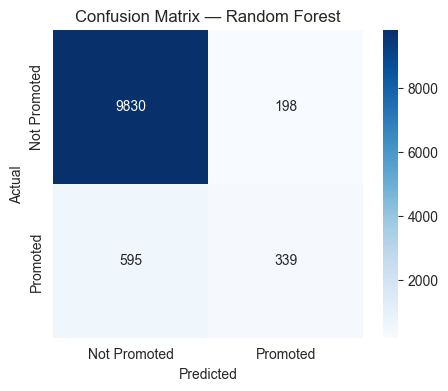


               precision    recall  f1-score   support

Not Promoted       0.94      0.98      0.96     10028
    Promoted       0.63      0.36      0.46       934

    accuracy                           0.93     10962
   macro avg       0.79      0.67      0.71     10962
weighted avg       0.92      0.93      0.92     10962



In [25]:
# Confusion matrix for the best model
best_name = results_df["f1"].astype(float).idxmax()
print(f"Best model by F1: {best_name}")

best = best_models[best_name]
y_pred = best.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Promoted", "Promoted"],
            yticklabels=["Not Promoted", "Promoted"])
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.show()

print("\n", classification_report(y_test, y_pred,
                                   target_names=["Not Promoted", "Promoted"]))

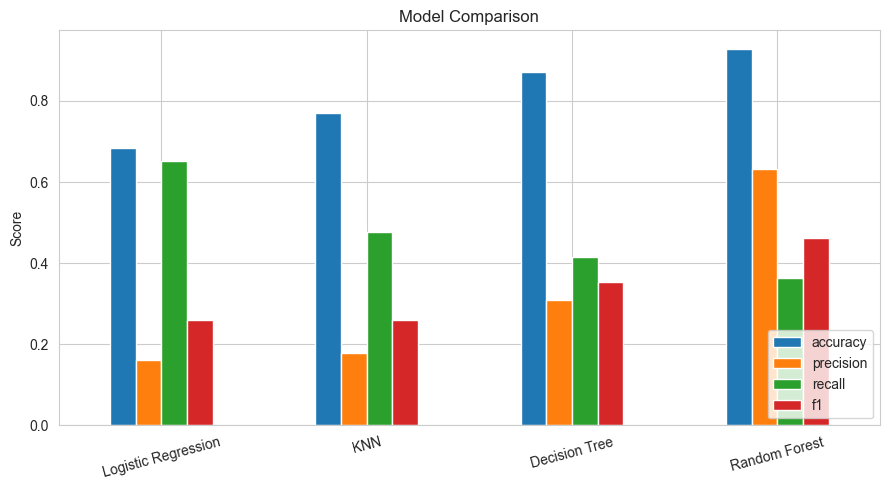

In [26]:
# Visual comparison of all models
results_df[["accuracy", "precision", "recall", "f1"]].astype(float).plot(
    kind="bar", figsize=(9, 5))
plt.title("Model Comparison")
plt.ylabel("Score"); plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

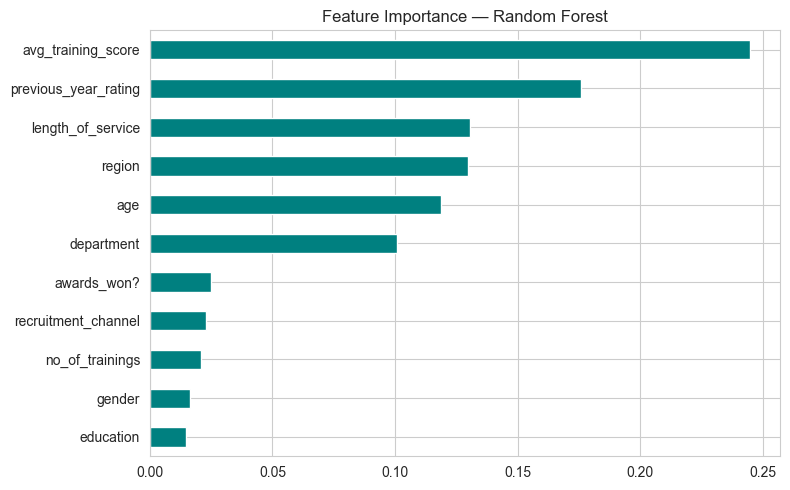

In [27]:
# Feature importance from Random Forest
if "Random Forest" in best_models:
    rf = best_models["Random Forest"]
    feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
    plt.figure(figsize=(8, 5))
    feat_imp.plot(kind="barh", color="teal")
    plt.title("Feature Importance — Random Forest")
    plt.tight_layout()
    plt.show()

## 10. Conclusion

### Key Findings
- **Random Forest was the best-performing model** with ~92.7% accuracy and the highest ROC-AUC (~0.77).
- **`avg_training_score`, `previous_year_rating`, and `awards_won?`** are the top drivers of promotion.
- SMOTE was essential — without it, models would just predict "not promoted" every time and still hit 91% accuracy while being useless.
- Logistic Regression had high recall but very low precision — it flags too many false positives.

### Limitations
- **Label encoding** treats `region` / `department` as ordered, which isn't accurate. One-hot encoding would be better.
- The dataset is from a single company and may not generalize.
- Recall for the "promoted" class is still modest (~36% with Random Forest) — we miss many real promotions.

### Future Improvements
- Try **XGBoost** and **Gradient Boosting** (listed in the guidelines) for likely better performance.
- Use **one-hot encoding** for nominal categoricals.
- Tune the **decision threshold** to trade precision for recall based on business needs.
- Add engineered features like `score_per_training` or `service_to_age_ratio`.

---

## 11. References
1. Scikit-learn documentation — https://scikit-learn.org
2. imbalanced-learn (SMOTE) — https://imbalanced-learn.org
3. Pandas documentation — https://pandas.pydata.org
4. HR Analytics dataset (employee promotion)
5. Seaborn visualization library — https://seaborn.pydata.org
